In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings,itertools
from scipy import stats
from sklearn.feature_selection import mutual_info_classif,mutual_info_regression
import os

os.makedirs("Graphs", exist_ok=True)
_original_show = plt.show
plt.show = lambda *args, **kwargs: (plt.savefig(f"Graphs/{plt.gca().get_title() or f'Figure_{plt.gcf().number}'}.png", dpi=150, bbox_inches="tight"), _original_show(*args, **kwargs))

fontname='Times New Roman'
if fontname not in {f.name for f in fm.fontManager.ttflist}:
    warnings.warn(f"{fontname} not found, using DejaVu Serif")
    fontname='DejaVu Serif'

maxcols=3
cellwidth=5
cellheight=4
singlesize=(8,5)
topn=6

def setGraphStyle():
    sns.set_style('whitegrid')
    plt.rcParams['font.family']=fontname
    plt.rcParams['font.size']=15
    plt.rcParams['axes.labelweight']='bold'
    plt.rcParams['axes.titlesize']=15
    plt.rcParams['figure.dpi']=150

def gridAxes(n):
    ncols=min(maxcols,n)
    nrows=int(np.ceil(n/ncols))
    fig,axes=plt.subplots(nrows,ncols,figsize=(cellwidth*ncols,cellheight*nrows))
    axes=np.array(axes).reshape(-1)
    return fig,axes

def showFig(fig):
    fig.tight_layout()
    plt.show()
    plt.close(fig)

def datasetOverview(df):
    rows,cols=df.shape
    names=df.columns.tolist()
    types=df.dtypes.astype(str).tolist()
    return rows,cols,names,types

def checkMissing(df):
    miss=df.isnull().sum()
    dup=df.duplicated().sum()
    single=[c for c in df.columns if df[c].nunique()==1]
    empty=[c for c in df.columns if df[c].isnull().all()]
    mixed=[]
    obj=df.select_dtypes(include=['object','string']).columns
    for c in obj:
        if c in empty:
            continue
        s=df[c].dropna().astype(str)
        if s.empty:
            continue
        if s.str.match(r'^-?\d+(\.\d+)?$').all():
            mixed.append(c)
    return miss,dup,single,empty,mixed

def analyzeNumeric(df):
    num=df.select_dtypes(include=['number'])
    if num.empty:
        return None
    summary=num.describe().T
    summary=summary.rename(columns={'mean':'Mean','std':'Std','min':'Min','max':'Max','50%':'Median','25%':'Q1','75%':'Q3'})
    summary['Mode']=num.mode().iloc[0]
    summary['Range']=summary['Max']-summary['Min']
    summary['Skewness']=num.skew()
    summary['Kurtosis']=num.kurt()
    cols=['Mean','Median','Mode','Std','Min','Max','Q1','Q3','Range','Skewness','Kurtosis']
    return summary[cols]

def analyzeCategorical(df):
    cat=df.select_dtypes(include=['object','string','category'])
    if cat.empty:
        return None
    data=[]
    for c in cat.columns:
        unique=cat[c].nunique()
        mode=cat[c].mode()
        top=mode.iloc[0] if not mode.empty else None
        freq=cat[c].value_counts().iloc[0] if not cat[c].value_counts().empty else 0
        data.append([c,unique,top,freq])
    return pd.DataFrame(data,columns=['Column','Unique','Top Value','Frequency'])

def analyzeNormality(df,alpha=0.05):
    num=df.select_dtypes(include=['number'])
    if num.empty:
        return None
    rows=[]
    for c in num.columns:
        data=num[c].dropna()
        if len(data)<3:
            continue
        sample=data.sample(min(len(data),5000),random_state=42)
        statval,p=stats.shapiro(sample)
        rows.append([c,statval,p,'Normal' if p>alpha else 'Not Normal'])
    return pd.DataFrame(rows,columns=['Column','Statistic','P-Value','Result'])

def mutualInfoAnalysis(df,target):
    if target not in df.columns:
        return None
    num=df.select_dtypes(include=['number']).drop(columns=[target],errors='ignore')
    if num.empty:
        return None
    X=num.fillna(num.median())
    y=df[target]
    if y.dtype=='object' or str(y.dtype)=='category' or y.nunique()<20:
        yenc=y.astype('category').cat.codes
        mi=mutual_info_classif(X,yenc,random_state=42)
    else:
        mi=mutual_info_regression(X,y,random_state=42)
    return pd.DataFrame({'Feature':num.columns,'Mutual Information':mi}).sort_values('Mutual Information',ascending=False).reset_index(drop=True)

def detectOutliers(df):
    num=df.select_dtypes(include=['number'])
    if num.empty:
        return None
    data=[]
    for c in num.columns:
        q1=num[c].quantile(0.25)
        q3=num[c].quantile(0.75)
        iqr=q3-q1
        low=q1-1.5*iqr
        high=q3+1.5*iqr
        count=((num[c]<low)|(num[c]>high)).sum()
        data.append([c,count])
    return pd.DataFrame(data,columns=['Column','Outlier Count'])

def correlationAnalysis(df):
    num=df.select_dtypes(include=['number'])
    return num.corr() if not num.empty else None

def highCorrFeatures(df,limit=0.8):
    num=df.select_dtypes(include=['number'])
    if num.empty:
        return None
    corr=num.corr().abs()
    pairs=[]
    for i in range(len(corr.columns)):
        for j in range(i+1,len(corr.columns)):
            val=corr.iloc[i,j]
            if val>=limit:
                pairs.append([corr.columns[i],corr.columns[j],val])
    return pd.DataFrame(pairs,columns=['Feature1','Feature2','Correlation'])

def classDistribution(df,target):
    return df[target].value_counts() if target in df.columns else None

def plotTargetOverview(df,target,maxcats=30):
    if target not in df.columns:
        print(f'plotTargetOverview: {target} not in dataframe, skipped')
        return
    nunique=df[target].nunique()
    if df[target].dtype.name in ('object','category') or nunique<=maxcats:
        plotClassDistribution(df,target)
    else:
        print(f'plotTargetOverview: target has {nunique} unique values, treating as continuous - showing distribution histogram instead of class bars')
        plotHistogram(df,cols=[target])

def plotClassDistribution(df,target,maxcats=30):
    setGraphStyle()
    if target not in df.columns:
        print(f'plotClassDistribution: {target} not in dataframe, skipped')
        return
    counts=df[target].value_counts()
    if len(counts)>maxcats:
        print(f'plotClassDistribution: target has {len(counts)} unique values (>{maxcats}), skipped - this looks like a continuous target, use plotHistogram instead')
        return
    fig,ax=plt.subplots(figsize=singlesize)
    ax.bar(counts.index.astype(str),counts.values,color='#4C72B0')
    ax.tick_params(axis='x',rotation=45,labelsize=10)
    ax.set_xlabel(target)
    ax.set_ylabel('Count')
    ax.set_title(f'Class Distribution: {target}')
    showFig(fig)

def selectImportantFeatures(df,target=None,n=topn,midf=None):
    num=df.select_dtypes(include=['number'])
    if target is not None and target in num.columns:
        num=num.drop(columns=[target])
    if num.empty:
        return []
    if target is not None and target in df.columns:
        mi=midf if midf is not None else mutualInfoAnalysis(df,target)
        if mi is not None and not mi.empty:
            return mi['Feature'].head(n).tolist()
    return num.var().sort_values(ascending=False).head(n).index.tolist()

def plotHistogram(df,cols=None):
    setGraphStyle()
    num=df.select_dtypes(include=['number'])
    if cols is not None:
        num=num[[c for c in cols if c in num.columns]]
    if num.empty:
        print('plotHistogram: no numeric columns, skipped')
        return
    fig,axes=gridAxes(len(num.columns))
    for i,c in enumerate(num.columns):
        axes[i].hist(num[c].dropna(),bins=30,color='#4C72B0',edgecolor='white')
        axes[i].set_xlabel(c)
        axes[i].set_ylabel('Frequency')
        axes[i].set_title(f'Histogram of {c}')
    for j in range(len(num.columns),len(axes)):
        fig.delaxes(axes[j])
    showFig(fig)

def plotBoxplot(df,cols=None):
    setGraphStyle()
    num=df.select_dtypes(include=['number'])
    if cols is not None:
        num=num[[c for c in cols if c in num.columns]]
    if num.empty:
        print('plotBoxplot: no numeric columns, skipped')
        return
    fig,axes=gridAxes(len(num.columns))
    for i,c in enumerate(num.columns):
        axes[i].boxplot(num[c].dropna(),patch_artist=True,boxprops=dict(facecolor='#DD8452'))
        axes[i].set_ylabel(c)
        axes[i].set_title(f'Boxplot of {c}')
    for j in range(len(num.columns),len(axes)):
        fig.delaxes(axes[j])
    showFig(fig)

def plotBargraph(df,cols=None):
    setGraphStyle()
    cat=df.select_dtypes(include=['object','string','category'])
    if cols is not None:
        cat=cat[[c for c in cols if c in cat.columns]]
    if cat.empty:
        print('plotBargraph: no categorical columns, skipped')
        return
    fig,axes=gridAxes(len(cat.columns))
    for i,c in enumerate(cat.columns):
        vc=cat[c].value_counts().head(15)
        axes[i].bar(vc.index.astype(str),vc.values,color='#55A868')
        axes[i].tick_params(axis='x',rotation=45,labelsize=10)
        axes[i].set_xlabel(c)
        axes[i].set_ylabel('Count')
        axes[i].set_title(f'Bar Chart of {c}')
    for j in range(len(cat.columns),len(axes)):
        fig.delaxes(axes[j])
    showFig(fig)

def plotScatter(df,pairs=None,maxpairs=6):
    setGraphStyle()
    num=df.select_dtypes(include=['number'])
    cols=list(num.columns)
    if len(cols)<2:
        print('plotScatter: fewer than 2 numeric columns, skipped')
        return
    if pairs is None:
        pairs=list(itertools.combinations(cols,2))[:maxpairs]
    fig,axes=gridAxes(len(pairs))
    for i,(a,b) in enumerate(pairs):
        axes[i].scatter(num[a],num[b],alpha=0.6,color='#8172B2',edgecolor='white',linewidth=0.3)
        axes[i].set_xlabel(a)
        axes[i].set_ylabel(b)
        axes[i].set_title(f'{a} vs {b}')
    for j in range(len(pairs),len(axes)):
        fig.delaxes(axes[j])
    showFig(fig)

def plotHeatmap(df,cols=None):
    setGraphStyle()
    num=df.select_dtypes(include=['number'])
    if cols is not None:
        num=num[[c for c in cols if c in num.columns]]
    if num.shape[1]<2:
        print('plotHeatmap: fewer than 2 numeric columns, skipped')
        return
    corr=num.corr()
    fig,ax=plt.subplots(figsize=singlesize)
    sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',square=True,cbar_kws={'label':'Correlation'},ax=ax,annot_kws={'fontsize':9,'fontname':fontname})
    ax.tick_params(axis='x',rotation=45,labelsize=10)
    ax.tick_params(axis='y',rotation=0,labelsize=10)
    ax.set_xlabel('Features')
    ax.set_ylabel('Features')
    ax.set_title('Correlation Heatmap')
    showFig(fig)

def plotMissingValues(df):
    setGraphStyle()
    miss=df.isnull().sum()
    miss=miss[miss>0].sort_values(ascending=False)
    if miss.empty:
        print('plotMissingValues: no missing values, skipped')
        return
    fig,ax=plt.subplots(figsize=singlesize)
    ax.bar(miss.index.astype(str),miss.values,color='#C44E52')
    ax.tick_params(axis='x',rotation=45,labelsize=10)
    ax.set_xlabel('Column')
    ax.set_ylabel('Missing Count')
    ax.set_title('Missing Values by Column')
    showFig(fig)

def plotOutliers(df):
    setGraphStyle()
    out=detectOutliers(df)
    if out is None or out['Outlier Count'].sum()==0:
        print('plotOutliers: no outliers detected, skipped')
        return
    fig,ax=plt.subplots(figsize=singlesize)
    ax.bar(out['Column'],out['Outlier Count'],color='#DD8452')
    ax.tick_params(axis='x',rotation=45,labelsize=10)
    ax.set_xlabel('Column')
    ax.set_ylabel('Outlier Count')
    ax.set_title('Outlier Count per Column (IQR method)')
    showFig(fig)

def generateCorePlots(df,target=None,n=topn,midf=None):
    important=selectImportantFeatures(df,target,n,midf=midf)
    if target is not None:
        plotTargetOverview(df,target)
    plotHeatmap(df)
    plotHistogram(df,cols=important)
    plotBoxplot(df,cols=important)

def generateAllPlots(df,target=None,n=topn,midf=None):
    plotMissingValues(df)
    generateCorePlots(df,target,n,midf=midf)
    plotOutliers(df)
    plotBargraph(df)
    plotScatter(df)

def edaSummary(df,target=None,full=False,n=topn):
    rows,cols,names,types=datasetOverview(df)
    miss,dup,single,empty,mixed=checkMissing(df)
    mi=mutualInfoAnalysis(df,target) if target is not None else None
    summary={"Rows":rows,"Columns":cols,"Column Names":names,"Data Types":types,"Missing Values":miss,
    "Duplicate Rows":dup,"Single Value Columns":single,"Empty Columns":empty,"Mixed Type Columns":mixed,
    "Numerical Summary":analyzeNumeric(df),"Categorical Summary":analyzeCategorical(df),
    "Normality Test":analyzeNormality(df),
    "Outlier Summary":detectOutliers(df),"Correlation Matrix":correlationAnalysis(df),
    "Highly Correlated Features":highCorrFeatures(df)}
    if target is not None:
        summary["Class Distribution"]=classDistribution(df,target)
        summary["Mutual Information"]=mi
    print('----- EDA Summary -----')
    for k,v in summary.items():
        print(f'{k}:')
        print(v)
        print()
    print('----- Generating Plots -----')
    if full:
        generateAllPlots(df,target,n,midf=mi)
    else:
        generateCorePlots(df,target,n,midf=mi)
    return summary

In [2]:
import pandas as pd

train=pd.read_csv('archive/train.csv')
train.head()

,Customer ID,Name,Gender,Age,Income (USD),Income Stability,Profession,Type of Employment,Location,Loan Amount Request (USD),...,Credit Score,No. of Defaults,Has Active Credit Card,Property ID,Property Age,Property Type,Property Location,Co-Applicant,Property Price,Loan Sanction Amount (USD)
0,C-36995,Frederica Shealy,F,56,1933.05,Low,Working,Sales staff,Semi-Urban,72809.58,...,809.44,0,NaN,746,1933.05,4,Rural,1,119933.46,54607.18
1,C-33999,America Calderone,M,32,4952.91,Low,Working,NaN,Semi-Urban,46837.47,...,780.40,0,Unpossessed,608,4952.91,2,Rural,1,54791.00,37469.98
2,C-3770,Rosetta Verne,F,65,988.19,High,Pensioner,NaN,Semi-Urban,45593.04,...,833.15,0,Unpossessed,546,988.19,2,Urban,0,72440.58,36474.43
3,C-26480,Zoe Chitty,F,65,NaN,High,Pensioner,NaN,Rural,80057.92,...,832.70,1,Unpossessed,890,NaN,2,Semi-Urban,1,121441.51,56040.54
4,C-23459,Afton Venema,F,31,2614.77,Low,Working,High skill tech staff,Semi-Urban,113858.89,...,745.55,1,Active,715,2614.77,4,Semi-Urban,1,208567.91,74008.28


In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sentinelcols=['Current Loan Expenses (USD)','Co-Applicant','Property Price','Loan Sanction Amount (USD)']
for c in sentinelcols:
    train[c]=train[c].replace(-999,np.nan)

train=train.dropna(subset=['Loan Sanction Amount (USD)']).reset_index(drop=True)

target='Loan Sanction Amount (USD)'
dropcols=['Customer ID','Name','Property ID',target]
X=train.drop(columns=dropcols)
y=train[target]

numcols=X.select_dtypes(include=['number']).columns.tolist()
catcols=X.select_dtypes(include=['object']).columns.tolist()

numPipe=Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())])
catPipe=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('encoder',OneHotEncoder(handle_unknown='ignore'))])
preprocessor=ColumnTransformer([('num',numPipe,numcols),('cat',catPipe,catcols)])

----- EDA Summary -----
Rows:
29322

Columns:
21

Column Names:
['Gender', 'Age', 'Income (USD)', 'Income Stability', 'Profession', 'Type of Employment', 'Location', 'Loan Amount Request (USD)', 'Current Loan Expenses (USD)', 'Expense Type 1', 'Expense Type 2', 'Dependents', 'Credit Score', 'No. of Defaults', 'Has Active Credit Card', 'Property Age', 'Property Type', 'Property Location', 'Co-Applicant', 'Property Price', 'Loan Sanction Amount (USD)']

Data Types:
['object', 'int64', 'float64', 'object', 'object', 'object', 'object', 'float64', 'float64', 'object', 'object', 'float64', 'float64', 'int64', 'object', 'float64', 'int64', 'object', 'float64', 'float64', 'float64']

Missing Values:
Gender                           51
Age                               0
Income (USD)                   4411
Income Stability               1628
Profession                        0
Type of Employment             7125
Location                          0
Loan Amount Request (USD)         0
Current Lo

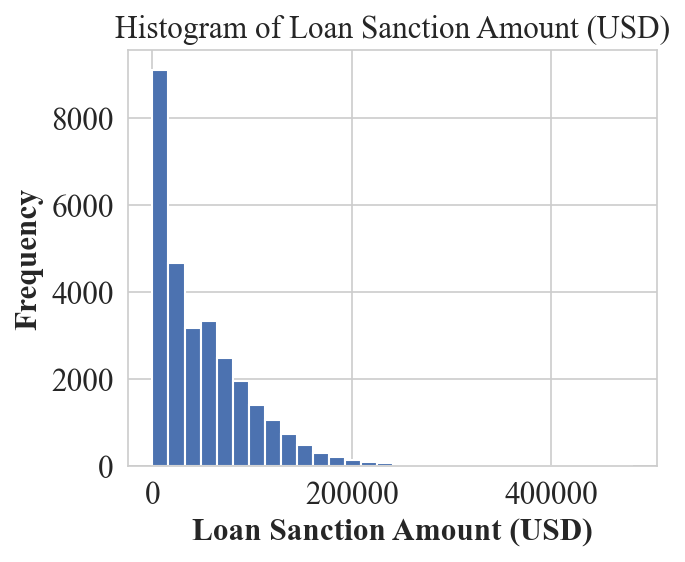

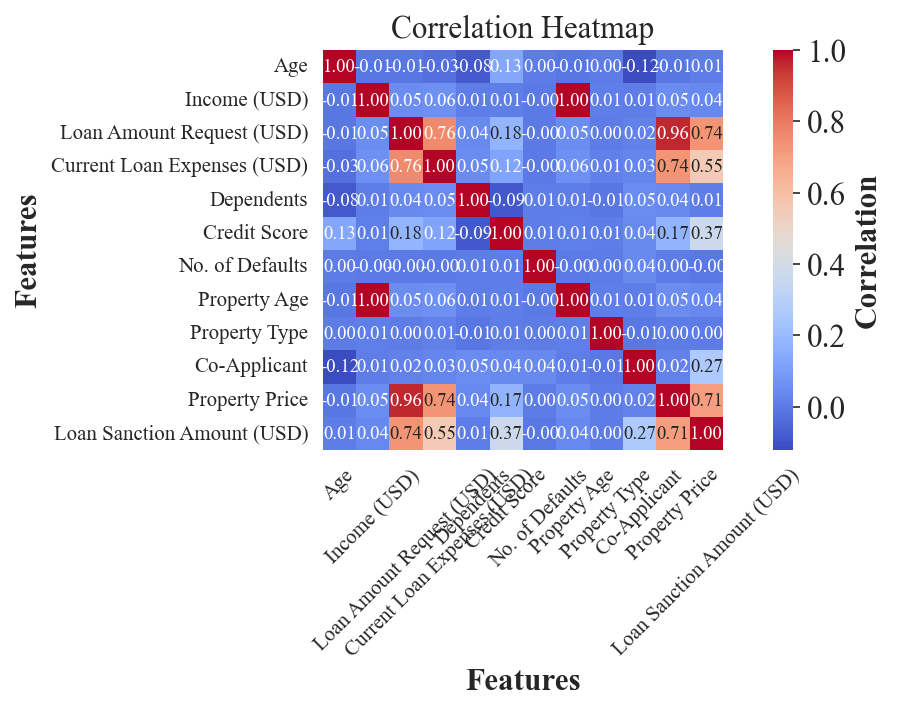

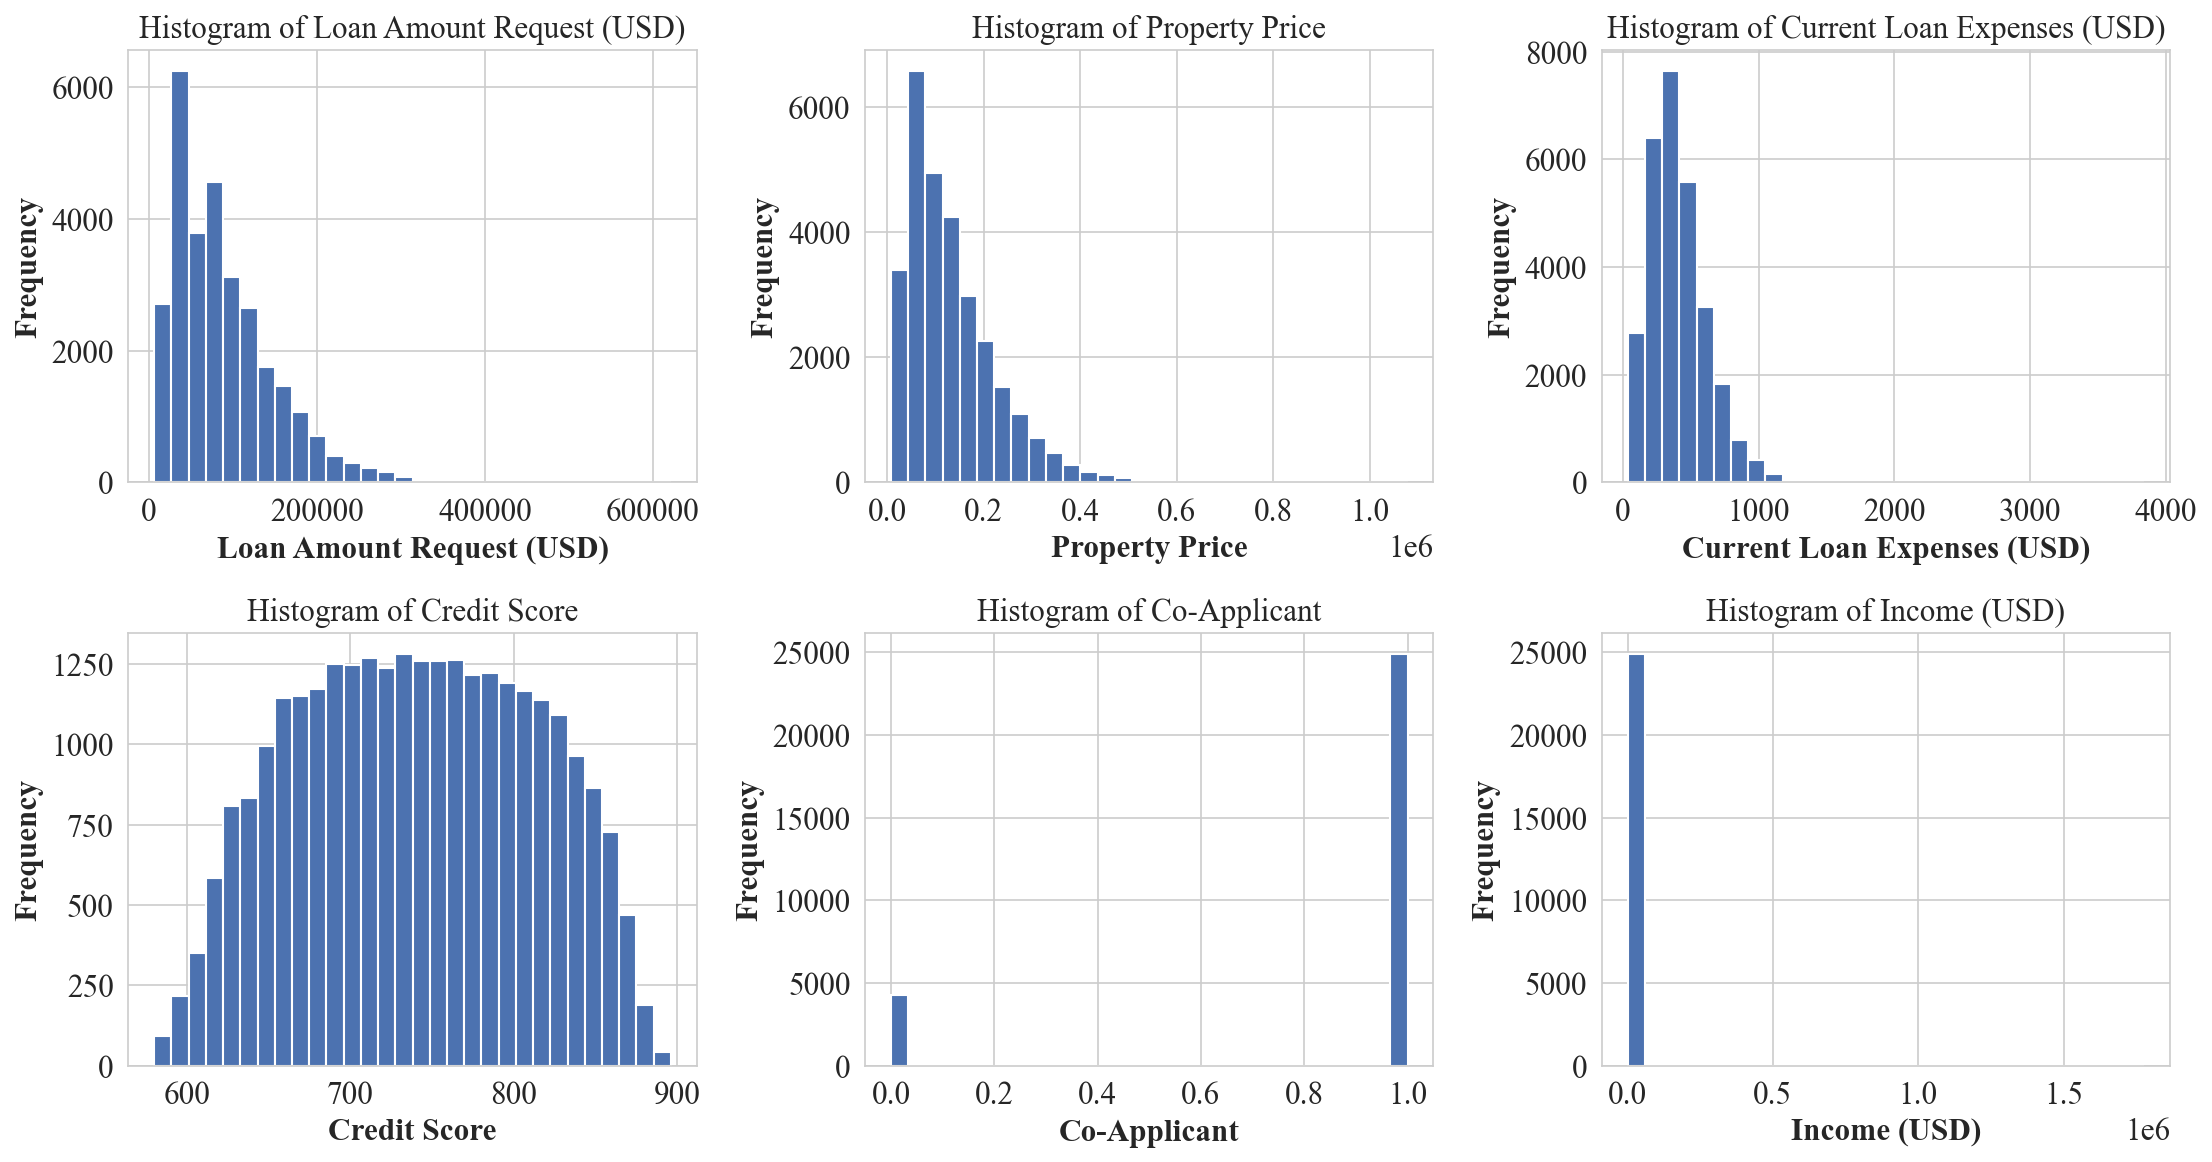

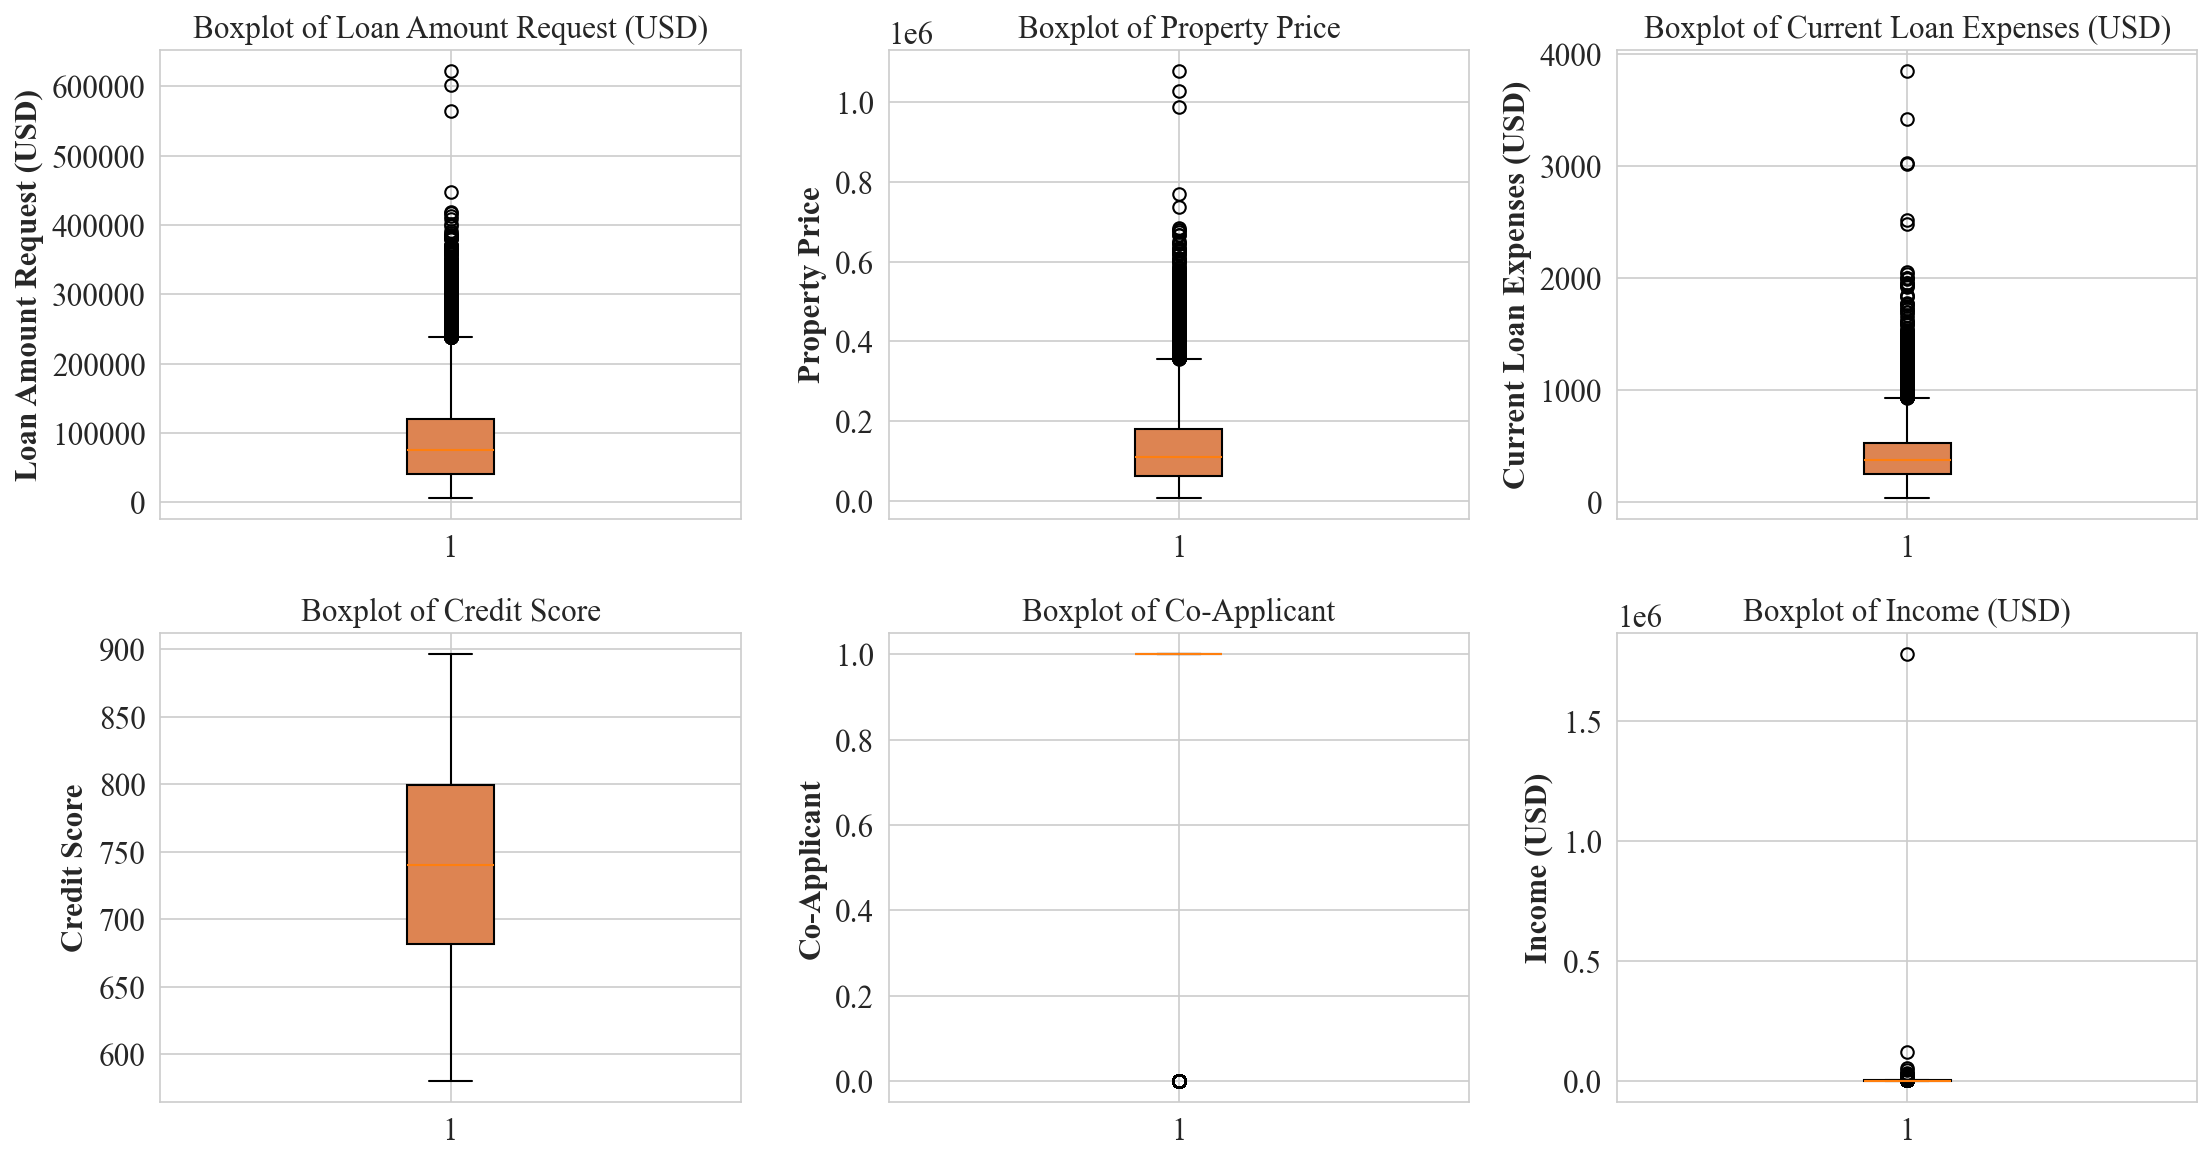

In [4]:
edaDf=X.copy()
edaDf[target]=y
summary=edaSummary(edaDf,target=target)

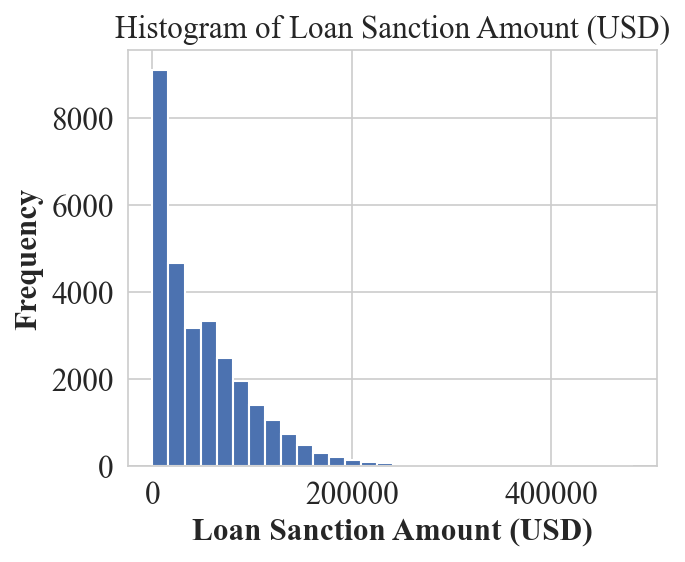

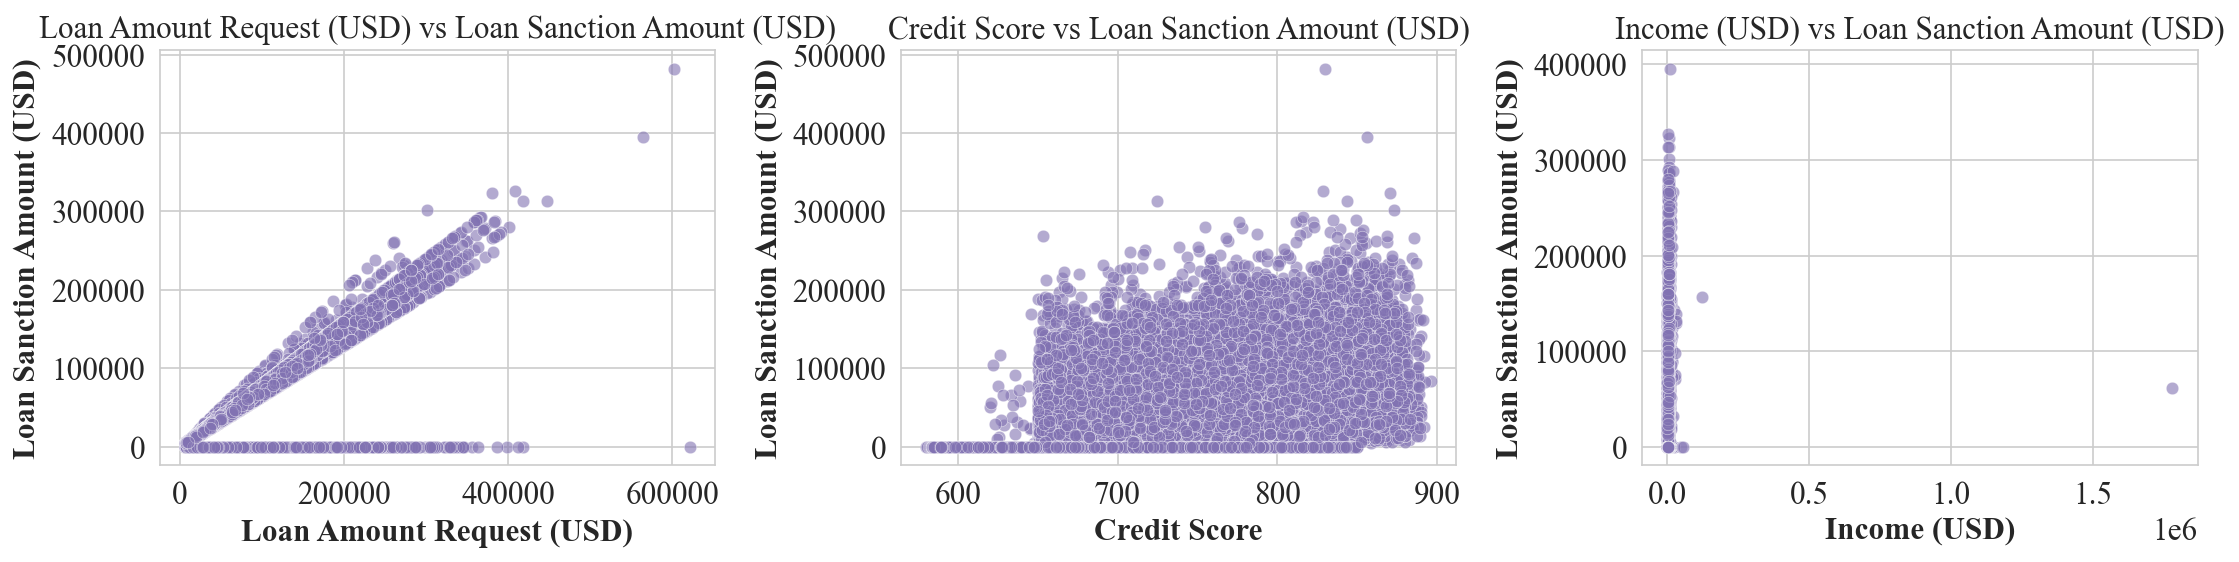

In [5]:
plotHistogram(edaDf,cols=[target])
plotScatter(edaDf,pairs=[('Loan Amount Request (USD)',target),('Credit Score',target),('Income (USD)',target)])

In [6]:
from sklearn.model_selection import train_test_split

Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
import time
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import cross_validate

def evaluateRegression(model,Xtrain,Xtest,ytrain,ytest,name="Model"):
    start=time.perf_counter()
    model.fit(Xtrain,ytrain)
    traintime=time.perf_counter()-start
    ypred=model.predict(Xtest)
    metrics={"Model":name,
    "MAE":mean_absolute_error(ytest,ypred),
    "MSE":mean_squared_error(ytest,ypred),
    "RMSE":np.sqrt(mean_squared_error(ytest,ypred)),
    "R2":r2_score(ytest,ypred),
    "Training Time":traintime}
    return metrics,ypred

def cvMetrics(model,Xtrain,ytrain,name):
    scoring={'MAE':'neg_mean_absolute_error','MSE':'neg_mean_squared_error','R2':'r2'}
    res=cross_validate(model,Xtrain,ytrain,cv=5,scoring=scoring)
    mae=-res['test_MAE'].mean()
    mse=-res['test_MSE'].mean()
    return {"Model":name,"MAE":mae,"MSE":mse,"RMSE":np.sqrt(mse),"R2":res['test_R2'].mean()}

In [8]:
from sklearn.linear_model import LinearRegression

linear=Pipeline([('prep',preprocessor),('model',LinearRegression())])
metricsLinear,predLinear=evaluateRegression(linear,Xtrain,Xtest,ytrain,ytest,"Linear Regression")
metricsLinear

{'Model': 'Linear Regression',
 'MAE': 18761.74879341826,
 'MSE': 770417853.4092427,
 'RMSE': np.float64(27756.40202564523),
 'R2': 0.6574900615536496,
 'Training Time': 0.3684062999673188}

In [9]:
from sklearn.linear_model import Ridge,Lasso,ElasticNet
from sklearn.model_selection import GridSearchCV

ridgePipe=Pipeline([('prep',preprocessor),('model',Ridge())])
ridgeGrid={'model__alpha':[0.01,0.1,1,10,100]}
ridgeSearch=GridSearchCV(ridgePipe,ridgeGrid,cv=5,scoring='r2',n_jobs=-1)
ridgeSearch.fit(Xtrain,ytrain)

lassoPipe=Pipeline([('prep',preprocessor),('model',Lasso(max_iter=5000))])
lassoGrid={'model__alpha':[0.001,0.01,0.1,1,10]}
lassoSearch=GridSearchCV(lassoPipe,lassoGrid,cv=5,scoring='r2',n_jobs=-1)
lassoSearch.fit(Xtrain,ytrain)

enetPipe=Pipeline([('prep',preprocessor),('model',ElasticNet(max_iter=5000))])
enetGrid={'model__alpha':[0.01,0.1,1,10],'model__l1_ratio':[0.2,0.5,0.8]}
enetSearch=GridSearchCV(enetPipe,enetGrid,cv=5,scoring='r2',n_jobs=-1)
enetSearch.fit(Xtrain,ytrain);

In [10]:
table1=pd.DataFrame([
{"Model":"Ridge Regression","Search Method":"Grid","Best Parameters":ridgeSearch.best_params_,"Best CV R2":ridgeSearch.best_score_},
{"Model":"Lasso Regression","Search Method":"Grid","Best Parameters":lassoSearch.best_params_,"Best CV R2":lassoSearch.best_score_},
{"Model":"Elastic Net Regression","Search Method":"Grid","Best Parameters":enetSearch.best_params_,"Best CV R2":enetSearch.best_score_},
])
print(table1)

linearFresh=Pipeline([('prep',preprocessor),('model',LinearRegression())])
table2=pd.DataFrame([
cvMetrics(linearFresh,Xtrain,ytrain,"Linear Regression"),
cvMetrics(ridgeSearch.best_estimator_,Xtrain,ytrain,"Ridge Regression"),
cvMetrics(lassoSearch.best_estimator_,Xtrain,ytrain,"Lasso Regression"),
cvMetrics(enetSearch.best_estimator_,Xtrain,ytrain,"Elastic Net Regression")])
print(table2)

metricsRidge,predRidge=evaluateRegression(ridgeSearch.best_estimator_,Xtrain,Xtest,ytrain,ytest,"Ridge Regression")
metricsLasso,predLasso=evaluateRegression(lassoSearch.best_estimator_,Xtrain,Xtest,ytrain,ytest,"Lasso Regression")
metricsEnet,predEnet=evaluateRegression(enetSearch.best_estimator_,Xtrain,Xtest,ytrain,ytest,"Elastic Net Regression")
table3=pd.DataFrame([metricsLinear,metricsRidge,metricsLasso,metricsEnet]).drop(columns=['Training Time'])
print(table3)

featnames=linear.named_steps['prep'].get_feature_names_out()
table4=pd.DataFrame({
"Feature":featnames,
"Linear":linear.named_steps['model'].coef_,
"Ridge":ridgeSearch.best_estimator_.named_steps['model'].coef_,
"Lasso":lassoSearch.best_estimator_.named_steps['model'].coef_,
"ElasticNet":enetSearch.best_estimator_.named_steps['model'].coef_})
table4=table4.reindex(table4['Linear'].abs().sort_values(ascending=False).index).reset_index(drop=True)
print(table4.head(10))

                    Model Search Method  \
0        Ridge Regression          Grid   
1        Lasso Regression          Grid   
2  Elastic Net Regression          Grid   

                                  Best Parameters  Best CV R2  
0                             {'model__alpha': 1}    0.642552  
1                            {'model__alpha': 10}    0.642949  
2  {'model__alpha': 0.01, 'model__l1_ratio': 0.8}    0.642439  
                    Model           MAE           MSE          RMSE        R2
0       Linear Regression  18903.172695  8.379527e+08  28947.413420  0.642544
1        Ridge Regression  18900.057048  8.379337e+08  28947.084848  0.642552
2        Lasso Regression  18890.375896  8.369773e+08  28930.560234  0.642949
3  Elastic Net Regression  18898.807308  8.382009e+08  28951.699849  0.642439
                    Model           MAE           MSE          RMSE        R2
0       Linear Regression  18761.748793  7.704179e+08  27756.402026  0.657490
1        Ridge Regression

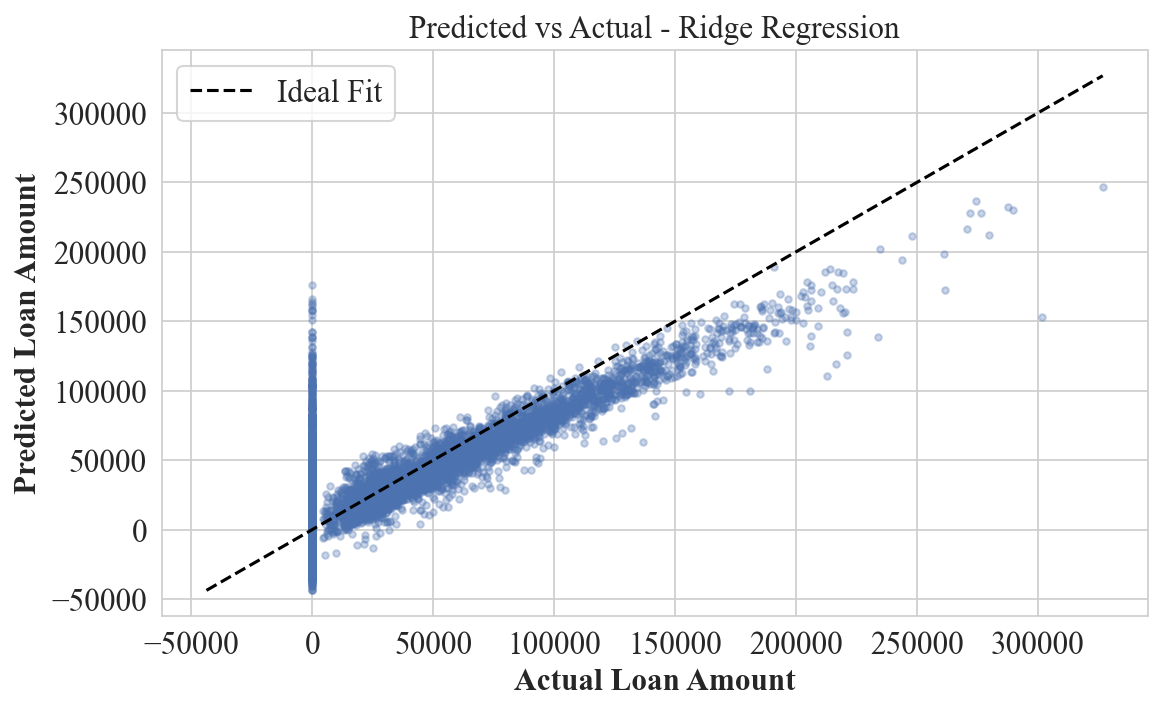

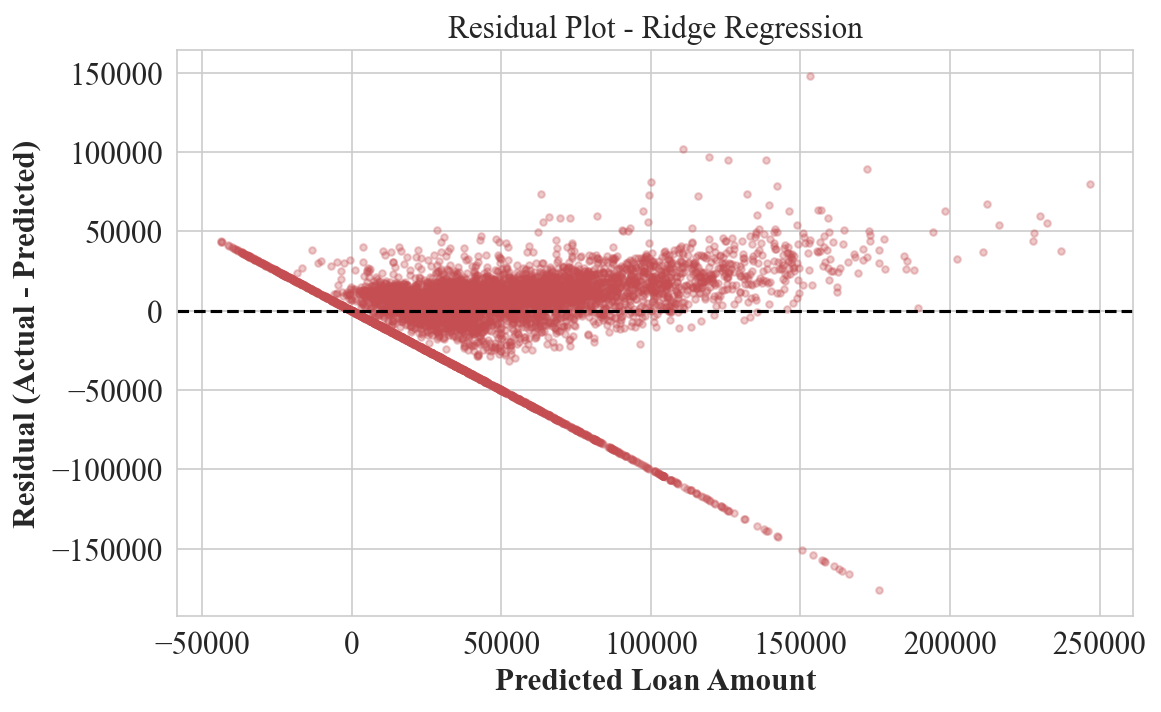

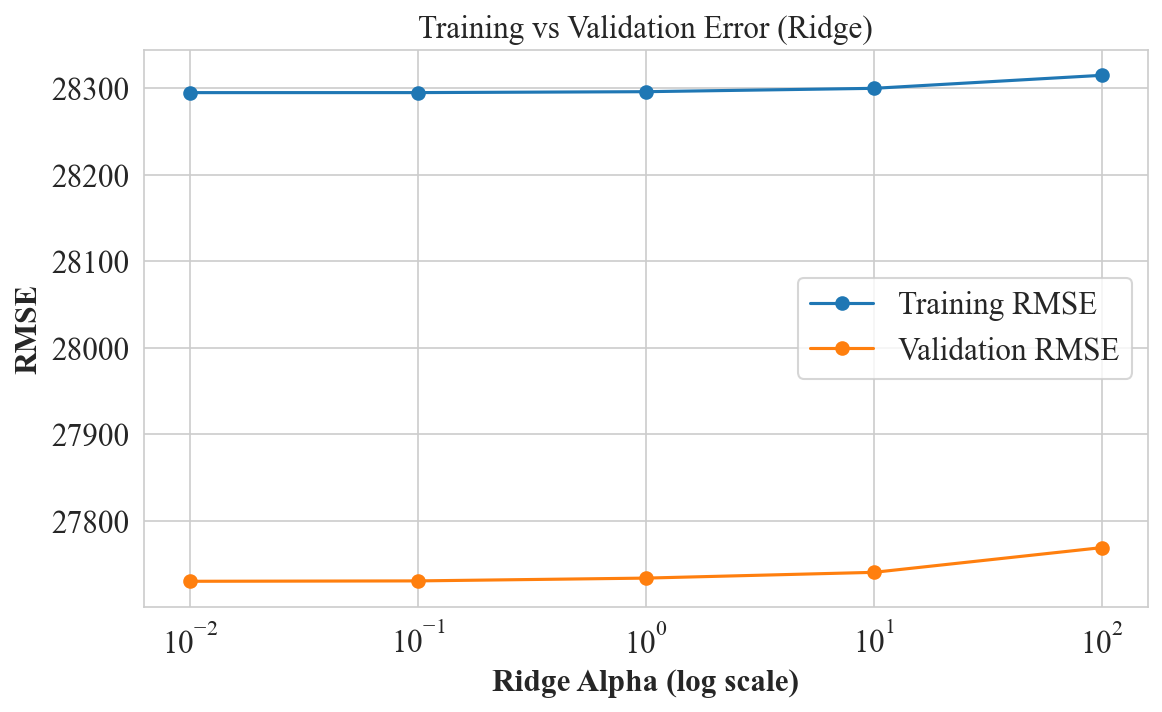

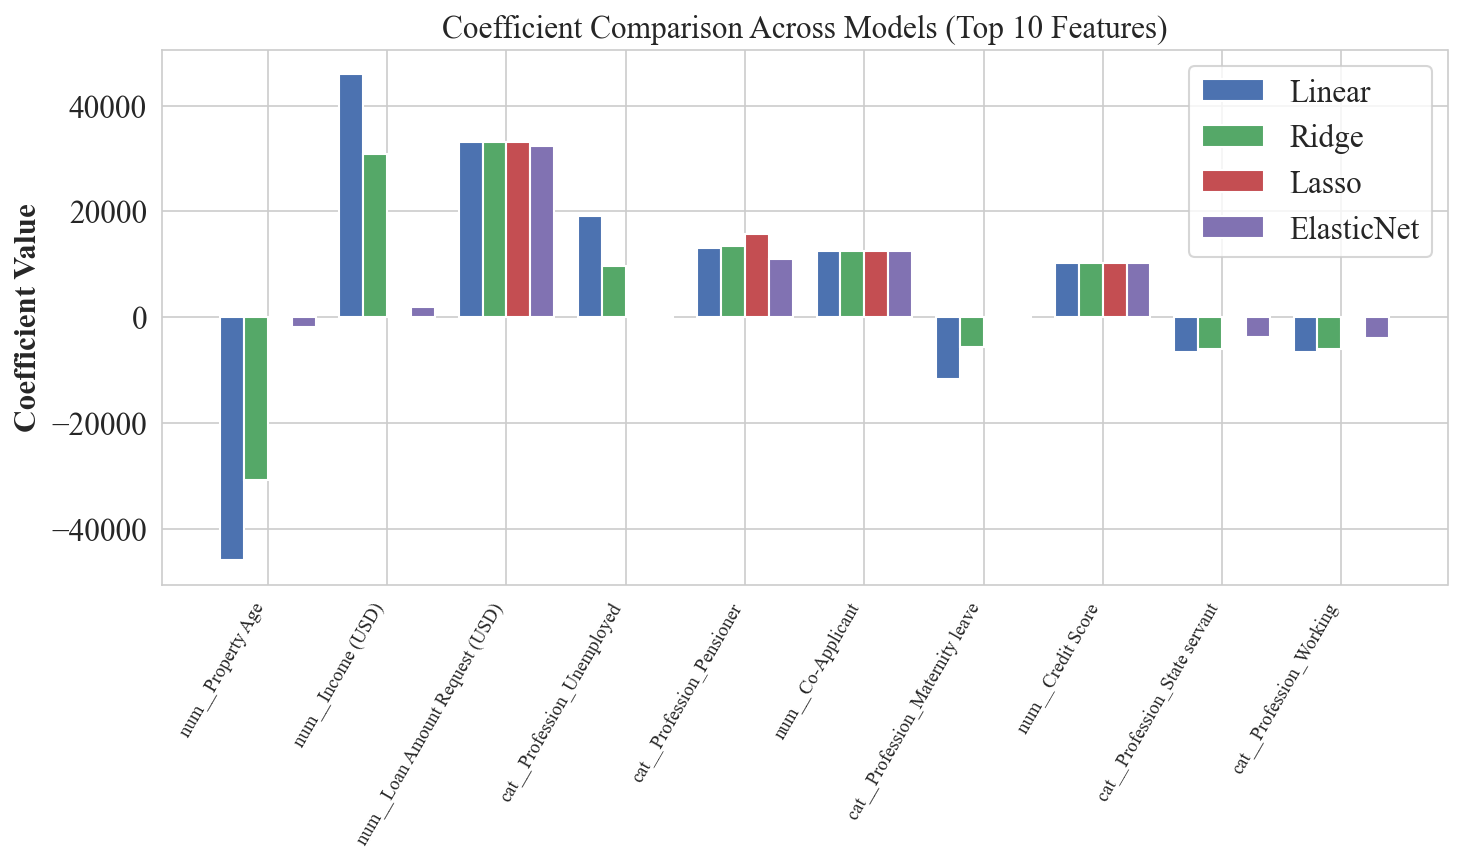

In [11]:
def plotPredictedVsActual(ytest,predictions,name):
    setGraphStyle()
    fig,ax=plt.subplots(figsize=singlesize)
    ax.scatter(ytest,predictions,alpha=0.3,color='#4C72B0',s=10)
    lims=[min(ytest.min(),predictions.min()),max(ytest.max(),predictions.max())]
    ax.plot(lims,lims,'k--',label='Ideal Fit')
    ax.set_xlabel('Actual Loan Amount')
    ax.set_ylabel('Predicted Loan Amount')
    ax.set_title(f'Predicted vs Actual - {name}')
    ax.legend()
    showFig(fig)

def plotResiduals(ytest,predictions,name):
    setGraphStyle()
    residuals=ytest-predictions
    fig,ax=plt.subplots(figsize=singlesize)
    ax.scatter(predictions,residuals,alpha=0.3,color='#C44E52',s=10)
    ax.axhline(0,color='black',linestyle='--')
    ax.set_xlabel('Predicted Loan Amount')
    ax.set_ylabel('Residual (Actual - Predicted)')
    ax.set_title(f'Residual Plot - {name}')
    showFig(fig)

def plotTrainValError(preprocessor,Xtrain,ytrain,alphas):
    setGraphStyle()
    trainerr=[]
    valerr=[]
    Xtr,Xval,ytr,yval=train_test_split(Xtrain,ytrain,test_size=0.2,random_state=42)
    for a in alphas:
        model=Pipeline([('prep',preprocessor),('model',Ridge(alpha=a))])
        model.fit(Xtr,ytr)
        trainerr.append(np.sqrt(((ytr-model.predict(Xtr))**2).mean()))
        valerr.append(np.sqrt(((yval-model.predict(Xval))**2).mean()))
    fig,ax=plt.subplots(figsize=singlesize)
    ax.plot(alphas,trainerr,marker='o',label='Training RMSE')
    ax.plot(alphas,valerr,marker='o',label='Validation RMSE')
    ax.set_xscale('log')
    ax.set_xlabel('Ridge Alpha (log scale)')
    ax.set_ylabel('RMSE')
    ax.set_title('Training vs Validation Error (Ridge)')
    ax.legend()
    showFig(fig)

def plotCoefficientComparison(table4,topn=10):
    setGraphStyle()
    sub=table4.head(topn)
    x=np.arange(len(sub))
    width=0.2
    fig,ax=plt.subplots(figsize=(10,6))
    ax.bar(x-1.5*width,sub['Linear'],width,label='Linear',color='#4C72B0')
    ax.bar(x-0.5*width,sub['Ridge'],width,label='Ridge',color='#55A868')
    ax.bar(x+0.5*width,sub['Lasso'],width,label='Lasso',color='#C44E52')
    ax.bar(x+1.5*width,sub['ElasticNet'],width,label='ElasticNet',color='#8172B2')
    ax.set_xticks(x)
    ax.set_xticklabels(sub['Feature'],rotation=60,ha='right',fontsize=9)
    ax.set_ylabel('Coefficient Value')
    ax.set_title('Coefficient Comparison Across Models (Top 10 Features)')
    ax.legend()
    showFig(fig)

plotPredictedVsActual(ytest.values,predRidge,'Ridge Regression')
plotResiduals(ytest.values,predRidge,'Ridge Regression')
plotTrainValError(preprocessor,Xtrain,ytrain,[0.01,0.1,1,10,100])
plotCoefficientComparison(table4)